# 000978 stage 3 — nonlinear embeddings (UMAP / CEBRA)

**50 ms smoothed** embeddings (σ=100 ms, speed > 4 cm/s) from
`src/common/embed_smoothed.py`, on **run** epochs. Three embeddings: **UMAP**
(unsupervised), **CEBRA-Time** (unsupervised, `cebratime`), and **CEBRA**
(supervised, trained on position+speed, NOT the session label). Colouring by
run_session reveals learning drift rather than building it in; the unsupervised
methods carry the honest signal.

1. 3-D embeddings coloured by run session and by position
2. CEBRA training loss (both variants)
3. Position decoding (kNN, CV) per method and region
4. Cross-session drift — per-session embedding centroids (preview of 6b)
5. **Track ↔ manifold** — 2-D trajectory and 3-D UMAP manifold sharing a
   linearized-position colour map (`SESSIONS` / `OUTLIER_Z` selectors)
6. **Interactive 3-D manifold** (plotly) — coloured by linearized position
7. **Interactive 3-D manifold** (plotly) — coloured by run session (drift view)

## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from config import processed_dir
DATA_PROCESSED = processed_dir("000978")
BIN_MS = 50                       # smoothed fine-bin path (sigma=100 ms, speed > 4 cm/s)
# 50 ms embeddings: UMAP + both CEBRA variants (supervised & unsupervised CEBRA-Time)
METHODS = ["umap", "cebratime", "cebra"]
plt.rcParams["figure.dpi"] = 100

## Pick a session/region

In [2]:
keys = sorted({f.stem.split("_")[2] for f in DATA_PROCESSED.glob(f"emb_umap_*_{BIN_MS}ms.npz")})
print("session keys:", keys)
SESSION = keys[0]   # change me (e.g. a single-file animal has 8 run sessions)
REGION = "CA1"
emb = {}
for m in METHODS:
    f = DATA_PROCESSED / f"emb_{m}_{SESSION}_{REGION}_{BIN_MS}ms.npz"
    if f.exists():
        emb[m] = np.load(f, allow_pickle=False)
print(f"{SESSION} {REGION}: methods", list(emb))

session keys: ['ER1', 'JS14', 'JS15', 'JS17', 'JS21', 'JS34', 'KL8']
ER1 CA1: methods ['umap', 'cebratime', 'cebra']


## 1. Embeddings by run session and position
Top: run session (1→N). Bottom: x-position.

C:\Users\proskurinm\AppData\Local\Temp\ipykernel_35048\3357613395.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


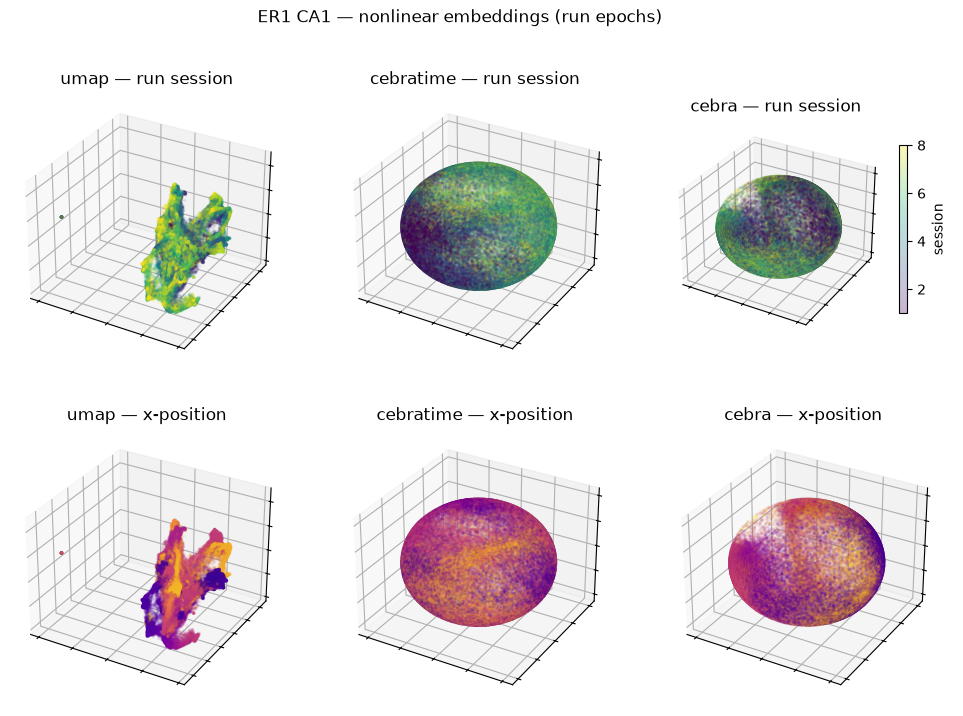

In [3]:
avail = list(emb)
fig = plt.figure(figsize=(4 * len(avail), 8))
for j, m in enumerate(avail):
    e = emb[m]["embedding"]; rs = emb[m]["run_session"]; pos = emb[m]["position"]
    ax = fig.add_subplot(2, len(avail), j + 1, projection="3d")
    s = ax.scatter(e[:, 0], e[:, 1], e[:, 2], c=rs, cmap="viridis", s=2, alpha=0.3)
    ax.set_title(f"{m} — run session"); [a.set_ticklabels([]) for a in (ax.xaxis, ax.yaxis, ax.zaxis)]
    if j == len(avail) - 1: fig.colorbar(s, ax=ax, label="session", shrink=0.6)
    ax2 = fig.add_subplot(2, len(avail), len(avail) + j + 1, projection="3d")
    ax2.scatter(e[:, 0], e[:, 1], e[:, 2], c=pos[:, 0], cmap="plasma", s=2, alpha=0.3)
    ax2.set_title(f"{m} — x-position"); [a.set_ticklabels([]) for a in (ax2.xaxis, ax2.yaxis, ax2.zaxis)]
fig.suptitle(f"{SESSION} {REGION} — nonlinear embeddings (run epochs)")
plt.tight_layout()

## 2. CEBRA training loss

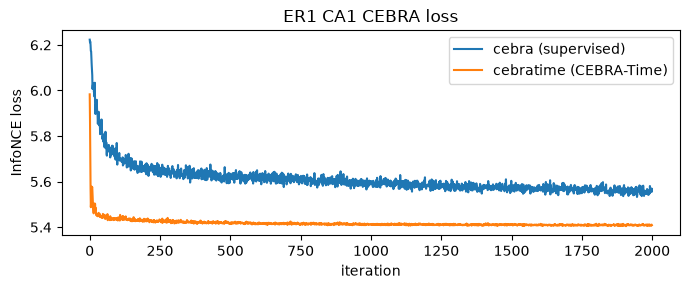

In [4]:
fig, ax = plt.subplots(figsize=(7, 3)); plotted = False
for m in ("cebra", "cebratime"):
    if m in emb and "cebra_loss" in emb[m].files:
        ax.plot(emb[m]["cebra_loss"], label=f"{m} ({'supervised' if m=='cebra' else 'CEBRA-Time'})")
        plotted = True
if plotted:
    ax.set_xlabel("iteration"); ax.set_ylabel("InfoNCE loss"); ax.legend()
    ax.set_title(f"{SESSION} {REGION} CEBRA loss"); plt.tight_layout()
else:
    print("no CEBRA loss (CEBRA not run yet?)")

## 3. Position decoding (kNN, 5-fold CV) per method and region

region,CA1,PFC
method,,
cebra,0.498,0.432
cebratime,0.102,0.264
umap,0.537,0.413


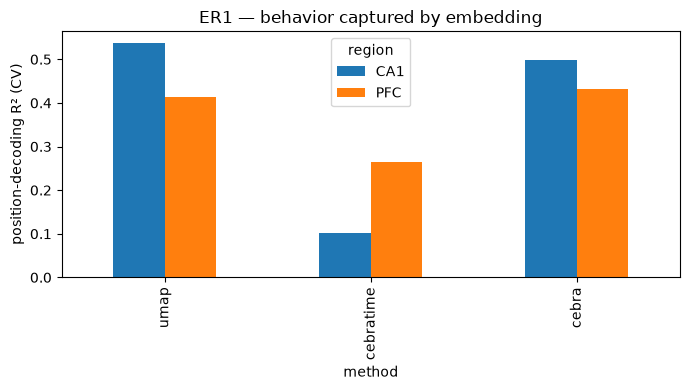

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
def decode_r2(e, pos):
    ok = np.isfinite(pos).all(axis=1)
    return cross_val_score(KNeighborsRegressor(15), e[ok], pos[ok], cv=5, scoring="r2").mean()
rows = []
for region in ["CA1", "PFC"]:
    for m in METHODS:
        f = DATA_PROCESSED / f"emb_{m}_{SESSION}_{region}_{BIN_MS}ms.npz"
        if f.exists():
            dd = np.load(f, allow_pickle=False)
            rows.append((region, m, decode_r2(dd["embedding"], dd["position"])))
tab = pd.DataFrame(rows, columns=["region", "method", "r2"]).pivot(index="method", columns="region", values="r2")
ax = tab.reindex(METHODS).plot.bar(figsize=(7, 4)); ax.set_ylabel("position-decoding R² (CV)")
ax.set_title(f"{SESSION} — behavior captured by embedding"); plt.tight_layout()
tab.round(3)

## 4. Cross-session drift (CEBRA)

Mean embedding position per run session. Systematic movement of the centroid
across sessions = learning-related manifold drift, quantified properly in 6b.

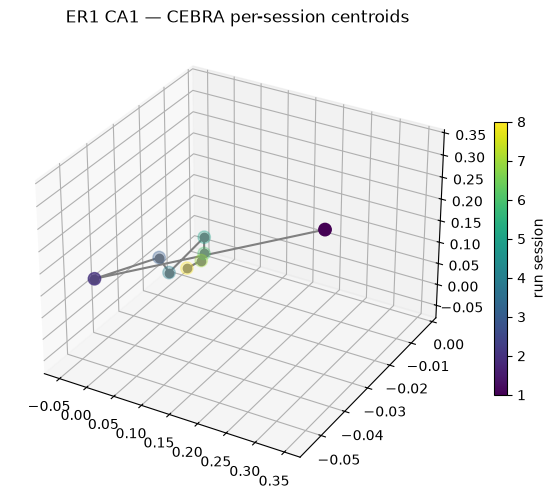

In [6]:
if "cebra" in emb:
    e = emb["cebra"]["embedding"]; rs = emb["cebra"]["run_session"]
    sessions = sorted(np.unique(rs).tolist())
    cent = np.vstack([e[rs == s].mean(0) for s in sessions])
    fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection="3d")
    ax.plot(cent[:, 0], cent[:, 1], cent[:, 2], "-o", color="gray", zorder=1)
    sc = ax.scatter(cent[:, 0], cent[:, 1], cent[:, 2], c=sessions, cmap="viridis", s=80, zorder=2)
    ax.set_title(f"{SESSION} {REGION} — CEBRA per-session centroids")
    fig.colorbar(sc, ax=ax, label="run session", shrink=0.6); plt.tight_layout()
else:
    print("CEBRA not available")

## 5. Track location ↔ neural-manifold location

Left: the 2-D trajectory on the W-track, each sample coloured by its
**linearized** position (left arm → base → centre → base → right arm). Right: the
**3-D** UMAP CA1 manifold for the same samples, same colour — a colour in the
manifold tells you where on the track that activity occurred. 000978 is a single
W across the day, so one track graph (wells from all trials); streams the NWB once.

- **`SESSIONS`** subselects run sessions — `None` = all, `[1]` = session 1, `[1, 8]`
  = first vs last (drift between early and late). §6 reuses this selection.
- **`OUTLIER_Z`** drops the occasional stray UMAP point (per-axis robust
  MAD z-score > threshold; the cell prints how many were removed).

A newer version (0.76.7) of dandi/dandi-cli is available. You are using 0.75.1


session 1, 8: 20710 bins plotted, 11 UMAP outliers removed (|MAD z| > 8)


Text(0.5, 0.98, 'Track location ↔ neural-manifold location — session 1, 8 (colour = linearized position)')

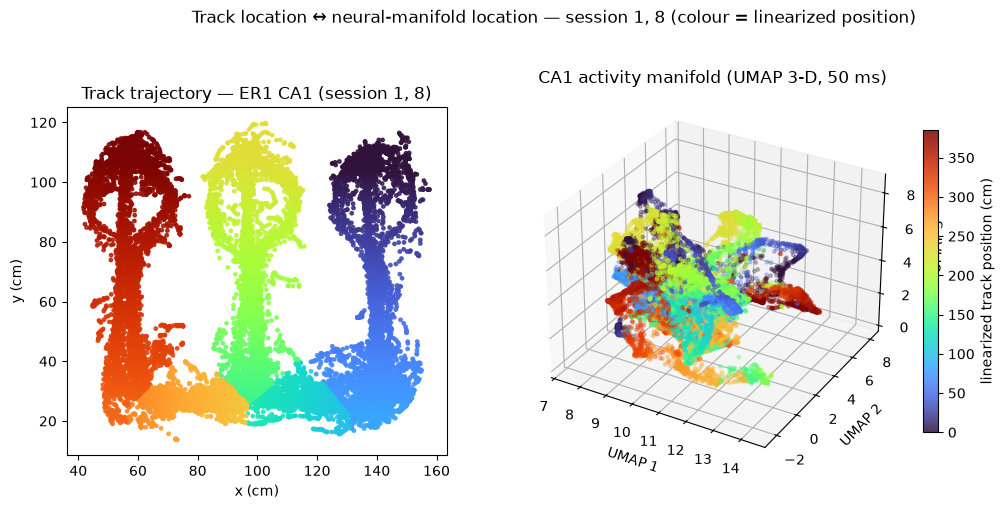

In [7]:
# Track location <-> neural manifold: colour both by LINEARIZED position (run epochs).
# 000978 is a single W across the day, so one track graph (wells from all trials).
import download as dl
import linearize as lz
from importlib import import_module
ex = import_module("01_extraction")

SESSIONS = [1, 8]          # subselect run sessions, e.g. [1] or [1, 8]; None = all
OUTLIER_Z = 8              # drop UMAP points with per-axis robust z > this (0/large = off)

u = emb["umap"]
posc, embc, rs = u["position"], u["embedding"], u["run_session"]
asset = next(p for p in dl.list_asset_paths(dandiset_id="000978")
             if p.endswith(".nwb") and ex.session_key(p) == SESSION)
with dl.stream_nwb(asset, dandiset_id="000978") as nwb:
    epochs = nwb.intervals[ex.EPOCH_TABLE].to_dataframe().reset_index(drop=True)
    trials = nwb.intervals["trials"].to_dataframe().reset_index(drop=True)
    kinds, _ = ex.classify_epochs(epochs, trials)
    ss = nwb.processing["behavior"].data_interfaces["Position"].spatial_series["SpatialSeries"]
    pos_t = np.asarray(ss.timestamps[:]); pos_xy = np.asarray(ss.data[:])[:, :2]
    run = np.zeros(len(pos_t), bool)
    for e, row in epochs.iterrows():
        if kinds[e] == "run":
            run |= (pos_t >= row.start_time) & (pos_t < row.stop_time)
    wells = lz.wells_from_trials(trials, pos_t, pos_xy)
    graph, eo, sp, _ = lz.build_wtrack_graph(pos_xy[run], wells=wells)
    lin, _ = lz.linearize_position(posc, graph, eo, sp)

# robust per-axis MAD z-score in UMAP space; keep points inside the cloud
med = np.median(embc, axis=0)
mad = np.median(np.abs(embc - med), axis=0) * 1.4826 + 1e-9
inlier = (np.abs(embc - med) / mad).max(axis=1) < OUTLIER_Z

sel = np.ones(len(posc), bool) if SESSIONS is None else np.isin(rs, SESSIONS)
base = sel & np.isfinite(lin) & np.isfinite(posc).all(axis=1)
ok = base & inlier
P, E, L, RS = posc[ok], embc[ok], lin[ok], rs[ok]     # RS = run session per plotted point
SESS_TXT = "all sessions" if SESSIONS is None else "session " + ", ".join(map(str, SESSIONS))
print(f"{SESS_TXT}: {len(P)} bins plotted, {int((base & ~inlier).sum())} UMAP outliers removed (|MAD z| > {OUTLIER_Z})")
order = np.argsort(L)                      # draw low->high so colour layering is stable

fig = plt.figure(figsize=(13, 5.6))
ax0 = fig.add_subplot(1, 2, 1)
s0 = ax0.scatter(P[order, 0], P[order, 1], c=L[order], cmap="turbo", s=6, alpha=0.85)
ax0.set_aspect("equal"); ax0.set_xlabel("x (cm)"); ax0.set_ylabel("y (cm)")
ax0.set_title(f"Track trajectory — {SESSION} {REGION} ({SESS_TXT})")
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
ax1.scatter(E[order, 0], E[order, 1], E[order, 2], c=L[order], cmap="turbo", s=6, alpha=0.7)
ax1.set_xlabel("UMAP 1"); ax1.set_ylabel("UMAP 2"); ax1.set_zlabel("UMAP 3")
ax1.set_title("CA1 activity manifold (UMAP 3-D, 50 ms)")
cb = fig.colorbar(s0, ax=[ax0, ax1], shrink=0.7, pad=0.02)
cb.set_label("linearized track position (cm)")
fig.suptitle(f"Track location ↔ neural-manifold location — {SESS_TXT} (colour = linearized position)")

## 6. Interactive 3-D manifold (plotly)

Same data as section 5, but interactive: **drag to rotate** the UMAP manifold,
scroll to zoom, hover for the linearized position. Both panels share the Turbo
colour map (track location ↔ manifold location). Renders inline in VS Code /
Jupyter.

In [8]:
# Interactive version (plotly): drag the manifold to rotate / zoom.
# Reuses P (2-D track), E (3-D UMAP), L (linearized position) and the SESSIONS
# selection from section 5; subsampled for a responsive browser figure.
from plotly.subplots import make_subplots
import plotly.graph_objects as go

_idx = (np.random.default_rng(0).choice(len(P), 20000, replace=False)
        if len(P) > 20000 else np.arange(len(P)))
Pp, Ep, Lp = P[_idx], E[_idx], L[_idx]

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.42, 0.58],
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=(f"Track trajectory — {SESSION} {REGION} ({SESS_TXT})",
                    "CA1 activity manifold (UMAP 3-D, 50 ms)"))
fig.add_trace(go.Scattergl(
    x=Pp[:, 0], y=Pp[:, 1], mode="markers",
    marker=dict(size=4, color=Lp, coloraxis="coloraxis"),
    hovertemplate="x=%{x:.0f}  y=%{y:.0f}<br>lin=%{marker.color:.0f} cm<extra></extra>"),
    row=1, col=1)
fig.add_trace(go.Scatter3d(
    x=Ep[:, 0], y=Ep[:, 1], z=Ep[:, 2], mode="markers",
    marker=dict(size=2.5, color=Lp, coloraxis="coloraxis", opacity=0.85),
    hovertemplate="UMAP=(%{x:.1f}, %{y:.1f}, %{z:.1f})<br>lin=%{marker.color:.0f} cm<extra></extra>"),
    row=1, col=2)
fig.update_xaxes(title_text="x (cm)", row=1, col=1)
fig.update_yaxes(title_text="y (cm)", scaleanchor="x", row=1, col=1)
fig.update_layout(
    coloraxis=dict(colorscale="Turbo", colorbar=dict(title="linearized<br>position (cm)")),
    scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
    width=1000, height=560, margin=dict(l=0, r=0, t=50, b=0), showlegend=False,
    title_text=f"Interactive — {SESS_TXT}, drag to rotate ({len(Pp)} of {len(P)} run bins shown)")
fig                                    # display as the cell's last expression

## 7. Interactive 3-D manifold — coloured by run session (drift view)

Same UMAP manifold as §5/§6, but points **coloured by run session** (viridis,
early→late) instead of by position, using the same `SESSIONS` selection (`[1, 8]`
= first vs last). Toggle sessions via the legend; drag to rotate. If the two
sessions occupy visibly offset regions, that's the manifold drift (quantified in
6b and §5 of the dimensionality notebook).

In [9]:
# Interactive 3-D manifold coloured by RUN SESSION (drift view).
# Reuses E (3-D UMAP), RS (session) and the SESSIONS selection from section 5.
import matplotlib as _mpl
import plotly.graph_objects as go

_idx = (np.random.default_rng(0).choice(len(E), 20000, replace=False)
        if len(E) > 20000 else np.arange(len(E)))
Es, RSs = E[_idx], RS[_idx]
sessvals = sorted(np.unique(RSs).tolist())
_cmap = _mpl.colormaps["viridis"]
scol = {s: _mpl.colors.to_hex(_cmap(k / max(len(sessvals) - 1, 1))) for k, s in enumerate(sessvals)}

fig = go.Figure()
for s in sessvals:
    m = RSs == s
    fig.add_trace(go.Scatter3d(
        x=Es[m, 0], y=Es[m, 1], z=Es[m, 2], mode="markers", name=f"session {s}",
        marker=dict(size=2.5, color=scol[s], opacity=0.7)))
fig.update_layout(
    scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
    width=760, height=640, margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(itemsizing="constant", title="run session"),
    title_text=f"{SESSION} {REGION} — UMAP 3-D coloured by run session ({SESS_TXT}); drag to rotate")
fig                                    # display as the cell's last expression

---
**Next:** 6b session-sequence alignment (Procrustes/CCA of each session's
embedding vs. the last, as a function of session number) and 6c sleep-epoch
projection. ZT2's two files need a global 1-8 session order first.